In [32]:
import sys

sys.path.insert(0, "../..")

import matplotlib.pyplot as plt
import numpy as np

In [33]:
def load_data(file_name):
    data = np.load(file_name)
    X = data["train_X"]
    Y = data["train_Y"]
    Y[:, 0] = -Y[:, 0]  # convert loss to positive
    Y[:, 2] = -100 * Y[:, 2]  # convert rippke to positive percent
    return X, Y

In [34]:
n_phases_rename = {3: ("3f", "black"), 5: ("5f", "red")}
t_target = 6.0
ripple_max = 10.0

In [35]:
X = {}
Y = {}
for n_phases in n_phases_rename:
    file_name = f"../../results/results_HacklGenerator_SixLambdas_{n_phases}f.npz"
    X[n_phases], Y[n_phases] = load_data(file_name)

In [36]:
import types

from machine_design.optimization import HacklGenerator_SixLambdas, plot_barriers

r_stator_end = 0.7
offset = 0.7 / 2
current_n = {3: 2, 5: 4}

for n_phases in n_phases_rename:
    if n_phases == 3:
        from motors.synrm_3f_60s import Geometry
    else:
        from motors.synrm_5f_60s import Geometry

    geometry = Geometry()
    design_dummy = types.SimpleNamespace(geometry=geometry)
    generator = HacklGenerator_SixLambdas(design_dummy, r_stator_end, offset=offset)
    feasible = (Y[n_phases][:, 1] >= t_target) & (Y[n_phases][:, 2] <= ripple_max)
    best_idx = np.where(feasible)[0][np.argmin(Y[n_phases][feasible, 0])]

    barrier_X = X[n_phases][best_idx, : -current_n[n_phases]]
    params = generator.X_to_params(barrier_X)
    generator.set_parameters(params)
    barriers = generator.generate_barriers()
    barriers = generator.split_barriers(barriers)

    label, color = n_phases_rename[n_phases]
    loss, torque, ripple = Y[n_phases][best_idx]
    title = f"{label}: loss={loss:.2f}, torque={torque:.2f}Nm, ripple={ripple:.2f}%"
    plot_barriers(barriers, design_dummy, title=title, file_name=f"best_rotor_{n_phases}f.png")

In [37]:
feasible_5f = (Y[5][:, 1] >= t_target) & (Y[5][:, 2] <= ripple_max)
best_idx_5f = np.where(feasible_5f)[0][np.argmin(Y[5][feasible_5f, 0])]

current_X = X[5][best_idx_5f, -current_n[5] :]
i1 = np.linalg.norm(current_X[:2])
i3 = np.linalg.norm(current_X[2:])
print(f"i1 magnitude={i1:.4f}, i3 magnitude={i3:.4f}, ratio={i3 / i1:.4f}")

i1 magnitude=0.8713, i3 magnitude=0.0507, ratio=0.0582


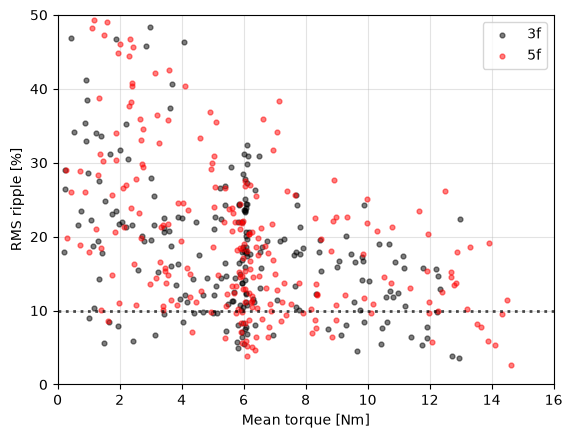

In [38]:
for n_phases, (label, color) in n_phases_rename.items():
    plt.scatter(Y[n_phases][:, 1], Y[n_phases][:, 2], color=color, s=12, alpha=0.5, label=label)

plt.axhline(ripple_max, color="black", linestyle=":", linewidth=2, alpha=0.7)
plt.xlim(0, 16)
plt.ylim(0, 50)
plt.xlabel("Mean torque [Nm]")
plt.ylabel("RMS ripple [%]")
plt.legend()
plt.grid(alpha=0.35)
ax = plt.gca()
ax.set_axisbelow(True)
plt.savefig("results.png", dpi=300, bbox_inches="tight")

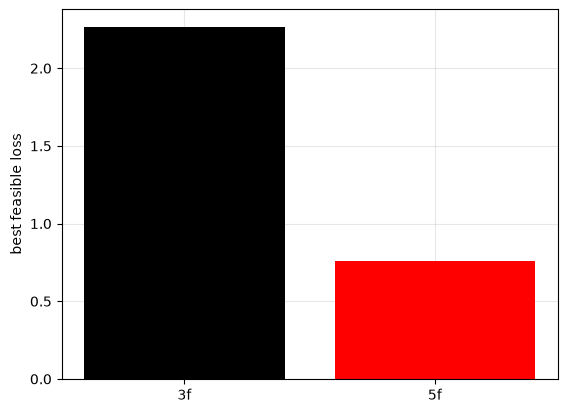

In [39]:
for n_phases, (label, color) in n_phases_rename.items():
    feasible = (Y[n_phases][:, 1] >= t_target) & (Y[n_phases][:, 2] <= ripple_max)
    best_loss = Y[n_phases][feasible, 0].min()
    plt.bar(label, best_loss, color=color)

plt.ylabel("best feasible loss")

plt.grid(alpha=0.3)

ax = plt.gca()
ax.set_axisbelow(True)

plt.savefig("best_loss.png", dpi=600, bbox_inches="tight")
plt.show()